### Import the necessary database

In [2]:
import numpy as np
import xarray as xr
import pandas as pd
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

In [3]:
#In[2]:
# define function
import src.SAT_function_Obs_Fingerprint as data_process
import src.Data_Preprocess as preprosess

In [4]:
# import src.slurm_cluster as scluster
# client, scluster = scluster.init_dask_slurm_cluster(scale=4, cores=50, memory="200GB")

In [6]:
# read all segmented trend patterns (L=10..73) into a dict of DataArrays
import os
dir_ICV_seg_TREND = '/work/mh0033/m301036/OBS_LPS_revision/docs/data/FIG3/OBS_ICV_std/'
len_segments = np.arange(10, 74, 1)

ds = {}
for L in len_segments:
    fpath = os.path.join(dir_ICV_seg_TREND, f"OBS_ICV_MK_trend_segments_L{L}.nc")
    da = xr.open_dataset(fpath, chunks={"lat": 10, "lon": 10})['trend']
    ds[f"ICV_trend_{L}yr"] = da


### Calculate the regional mean of each trend Length 

In [15]:
lat = ds["ICV_trend_10yr"].lat
lon = ds["ICV_trend_10yr"].lon
# Extratropical South Pacific region
lat1 = -70
lat2 = -55
lon1 = 180
lon2 = 260

ds_sop_masked = {}
for key in ds.keys():
    ds_sop_masked[key] = data_process.selreg(ds[key],lat, lon, lat1, lat2, lon1, lon2)

In [14]:
lon

<xarray.DataArray 'lon' (lon: 180)>
array([  0.,   2.,   4.,   6.,   8.,  10.,  12.,  14.,  16.,  18.,  20.,  22.,
        24.,  26.,  28.,  30.,  32.,  34.,  36.,  38.,  40.,  42.,  44.,  46.,
        48.,  50.,  52.,  54.,  56.,  58.,  60.,  62.,  64.,  66.,  68.,  70.,
        72.,  74.,  76.,  78.,  80.,  82.,  84.,  86.,  88.,  90.,  92.,  94.,
        96.,  98., 100., 102., 104., 106., 108., 110., 112., 114., 116., 118.,
       120., 122., 124., 126., 128., 130., 132., 134., 136., 138., 140., 142.,
       144., 146., 148., 150., 152., 154., 156., 158., 160., 162., 164., 166.,
       168., 170., 172., 174., 176., 178., 180., 182., 184., 186., 188., 190.,
       192., 194., 196., 198., 200., 202., 204., 206., 208., 210., 212., 214.,
       216., 218., 220., 222., 224., 226., 228., 230., 232., 234., 236., 238.,
       240., 242., 244., 246., 248., 250., 252., 254., 256., 258., 260., 262.,
       264., 266., 268., 270., 272., 274., 276., 278., 280., 282., 284., 286.,
       288., 290., 292., 294., 296., 298., 300., 302., 304., 306., 308., 310.,
       312., 314., 316., 318., 320., 322., 324., 326., 328., 330., 332., 334.,
       336., 338., 340., 342., 344., 346., 348., 350., 352., 354., 356., 358.])
Coordinates:
  * lon      (lon) float64 0.0 2.0 4.0 6.0 8.0 ... 350.0 352.0 354.0 356.0 358.0
Attributes:
    standard_name:  longitude
    long_name:      longitude
    units:          degrees_east
    axis:           X

In [23]:
# ds_sop_masked entries are tuples: (dataarray, lon, lat)
ds_sop_masked["ICV_trend_73yr"][0].isel(segment=1)

<xarray.DataArray 'trend' (lat: 9, lon: 41)>
dask.array<getitem, shape=(9, 41), dtype=float64, chunksize=(8, 10), chunktype=numpy.ndarray>
Coordinates:
  * lat      (lat) float64 -71.0 -69.0 -67.0 -65.0 -63.0 -61.0 -59.0 -57.0 -55.0
  * lon      (lon) float64 180.0 182.0 184.0 186.0 ... 254.0 256.0 258.0 260.0

In [9]:
def plot_trend(temp_data, lats, lons, levels=None, extend=None, cmap=None, 
                                 title="", ax=None, show_xticks=False, show_yticks=False):
    """
    Plot the trend spatial pattern using Robinson projection with significance overlaid.

    Parameters:
    - temp_data: 2D numpy array with the trend values.
    - lats, lons: 1D arrays of latitudes and longitudes.
    - p_values: 2D array with p-values for each grid point.
    - GMST_p_values: 2D array with GMST p-values for each grid point.
    - title: Title for the plot.
    - ax: Existing axis to plot on. If None, a new axis will be created.
    - show_xticks, show_yticks: Boolean flags to show x and y axis ticks.
    
    Returns:
    - contour_obj: The contour object from the plot.
    """
    # Plotting
    contour_obj = ax.contourf(lons, lats, temp_data, levels=levels, extend=extend, cmap=cmap, transform=ccrs.PlateCarree())

    ax.coastlines(resolution='110m')
    gl = ax.gridlines(draw_labels=True, dms=True, x_inline=False, y_inline=False,
                      color='gray', alpha=0.35, linestyle='--')

    # Disable labels on the top and right of the plot
    gl.top_labels = False
    gl.right_labels = False

    # Enable labels on the bottom and left of the plot
    gl.bottom_labels = show_xticks
    gl.left_labels = show_yticks
    gl.xformatter = cticker.LongitudeFormatter()
    gl.yformatter = cticker.LatitudeFormatter()
    gl.xlabel_style = {'size': 16}
    gl.ylabel_style = {'size': 16}
    
    if show_xticks:
        gl.bottom_labels = True
    if show_yticks:
        gl.left_labels = True
    
    # ax.set_title(title, loc='center', fontsize=18, pad=5.0)

    return contour_obj
# %%
plt.rcParams['figure.figsize'] = (8, 10)
plt.rcParams['font.size'] = 16
# plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['axes.labelsize'] = 16
plt.rcParams['ytick.direction'] = 'out'
plt.rcParams['ytick.minor.visible'] = True
plt.rcParams['ytick.major.right'] = True
plt.rcParams['ytick.right'] = True
plt.rcParams['xtick.bottom'] = True
plt.rcParams['savefig.dpi'] = 300
plt.rcParams['savefig.bbox'] = 'tight'
plt.rcParams['savefig.pad_inches'] = 0.1
plt.rcParams['savefig.transparent'] = True

import cartopy.crs as ccrs
import matplotlib.pyplot as plt
import matplotlib.colors as colors
import matplotlib.ticker as mticker
import cartopy.feature as cfeature
import cartopy.mpl.ticker as cticker
import matplotlib.patches as mpatches
import matplotlib.lines as mlines
import matplotlib.gridspec as gridspec
import matplotlib as mpl
import seaborn as sns
from matplotlib.colors import ListedColormap
from matplotlib.colors import BoundaryNorm, ListedColormap
import cartopy.util as cutil
import seaborn as sns
import matplotlib.colors as mcolors
import palettable

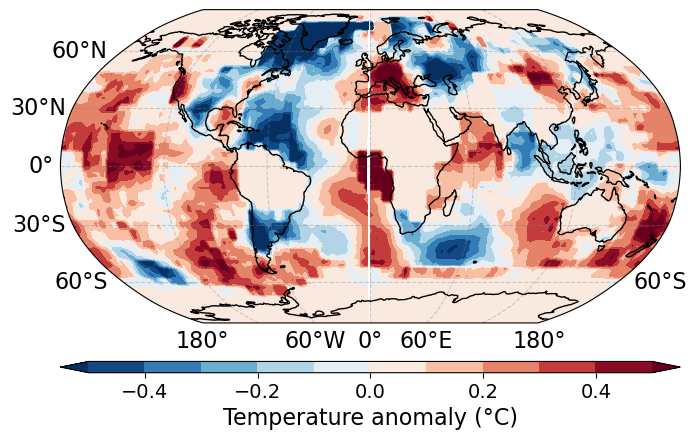

In [24]:
da_plot =ds["ICV_trend_10yr"].sel(segment=slice(1,10)).mean(dim='segment')

fig, ax = plt.subplots(subplot_kw={'projection': ccrs.Robinson()})

contour_obj =  plot_trend(da_plot, da_plot.lat, da_plot.lon, levels=np.arange(-0.5, 0.6, 0.1), extend='both', cmap='RdBu_r',
                                    title="SEP region SAT anomaly 2020", ax=ax, show_xticks=True, show_yticks=True)

# colorbar
cbar = plt.colorbar(contour_obj, ax=ax, orientation='horizontal', pad=0.05, aspect=50)
cbar.set_label('Temperature anomaly (°C)')
cbar.ax.tick_params(labelsize=14)

plt.show()

In [25]:
ds_sop_masked

{'ICV_trend_10yr': (<xarray.DataArray 'trend' (segment: 164, lat: 9, lon: 41)>
  dask.array<getitem, shape=(164, 9, 41), dtype=float64, chunksize=(164, 8, 10), chunktype=numpy.ndarray>
  Coordinates:
    * lat      (lat) float64 -71.0 -69.0 -67.0 -65.0 -63.0 -61.0 -59.0 -57.0 -55.0
    * lon      (lon) float64 180.0 182.0 184.0 186.0 ... 254.0 256.0 258.0 260.0
  Dimensions without coordinates: segment,
  <xarray.DataArray 'lon' (lon: 41)>
  array([180., 182., 184., 186., 188., 190., 192., 194., 196., 198., 200., 202.,
         204., 206., 208., 210., 212., 214., 216., 218., 220., 222., 224., 226.,
         228., 230., 232., 234., 236., 238., 240., 242., 244., 246., 248., 250.,
         252., 254., 256., 258., 260.])
  Coordinates:
    * lon      (lon) float64 180.0 182.0 184.0 186.0 ... 254.0 256.0 258.0 260.0
  Attributes:
      standard_name:  longitude
      long_name:      longitude
      units:          degrees_east
      axis:           X,
  <xarray.DataArray 'lat' (lat: 9)>
  a

In [26]:
# calculate the weighted regional mean anomalies of trend patterns
ds_sel_SOP_masked_mean = {}
for key in ds_sop_masked.keys():
    # ds_sop_masked entries are tuples (dataarray, lon, lat) -> pass the dataarray to the weighted mean
    ds_sel_SOP_masked_mean[key] = data_process.calc_weighted_mean(ds_sop_masked[key][0])

In [27]:
ds_sel_SOP_masked_mean

{'ICV_trend_10yr': <xarray.DataArray 'trend' (segment: 164)>
 dask.array<truediv, shape=(164,), dtype=float64, chunksize=(164,), chunktype=numpy.ndarray>
 Dimensions without coordinates: segment,
 'ICV_trend_11yr': <xarray.DataArray 'trend' (segment: 163)>
 dask.array<truediv, shape=(163,), dtype=float64, chunksize=(163,), chunktype=numpy.ndarray>
 Dimensions without coordinates: segment,
 'ICV_trend_12yr': <xarray.DataArray 'trend' (segment: 162)>
 dask.array<truediv, shape=(162,), dtype=float64, chunksize=(162,), chunktype=numpy.ndarray>
 Dimensions without coordinates: segment,
 'ICV_trend_13yr': <xarray.DataArray 'trend' (segment: 161)>
 dask.array<truediv, shape=(161,), dtype=float64, chunksize=(161,), chunktype=numpy.ndarray>
 Dimensions without coordinates: segment,
 'ICV_trend_14yr': <xarray.DataArray 'trend' (segment: 160)>
 dask.array<truediv, shape=(160,), dtype=float64, chunksize=(160,), chunktype=numpy.ndarray>
 Dimensions without coordinates: segment,
 'ICV_trend_15yr': <

### specify the 5 and 95 percentile values for each year step and output the 10-73yr unforced percentile timeseires for each regions

In [28]:
# define the function to calculate the percentile
def calc_percentile(da, q):
    """ Calculate the qth percentile of the data along the specified dimension.
    Args:
    da: xr.DataArray
    dim: str
    q: float
    Returns:
    xr.DataArray
    """
    # remove nans for da
    da = da.dropna(dim='segment')
    lower_percentile = np.percentile(da, q)
    upper_percentile = np.percentile(da, 100-q)
    
    return lower_percentile, upper_percentile

In [29]:
ds['ICV_trend_11yr']

<xarray.DataArray 'trend' (segment: 163, lat: 90, lon: 180)>
dask.array<open_dataset-a13757215e76170d6f332760606c3821trend, shape=(163, 90, 180), dtype=float64, chunksize=(163, 10, 10), chunktype=numpy.ndarray>
Coordinates:
  * lat      (lat) float64 -89.0 -87.0 -85.0 -83.0 -81.0 ... 83.0 85.0 87.0 89.0
  * lon      (lon) float64 0.0 2.0 4.0 6.0 8.0 ... 350.0 352.0 354.0 356.0 358.0
Dimensions without coordinates: segment

In [30]:
# calculate the regional mean's percentile
# 5%---[0]
unforced_trend_SOP_lower_percentile = {}

# 95%---[1]
unforced_trend_SOP_upper_percentile = {}

for key in ds_sel_SOP_masked_mean.keys():
    unforced_trend_SOP_lower_percentile[key], unforced_trend_SOP_upper_percentile[key] = calc_percentile(ds_sel_SOP_masked_mean[key], 5)
    

In [31]:
unforced_trend_SOP_lower_percentile

{'ICV_trend_10yr': -0.475395688609112,
 'ICV_trend_11yr': -0.4433350609039841,
 'ICV_trend_12yr': -0.37688934968582427,
 'ICV_trend_13yr': -0.32739139606286255,
 'ICV_trend_14yr': -0.31372448275728915,
 'ICV_trend_15yr': -0.27707357368794117,
 'ICV_trend_16yr': -0.23954788690155954,
 'ICV_trend_17yr': -0.23210530085033487,
 'ICV_trend_18yr': -0.21505662231924988,
 'ICV_trend_19yr': -0.20592508131788578,
 'ICV_trend_20yr': -0.19497457147911004,
 'ICV_trend_21yr': -0.18406469976819267,
 'ICV_trend_22yr': -0.17900120126759544,
 'ICV_trend_23yr': -0.16071163616719214,
 'ICV_trend_24yr': -0.15744363534671071,
 'ICV_trend_25yr': -0.14847617935852972,
 'ICV_trend_26yr': -0.12709248892337374,
 'ICV_trend_27yr': -0.13110772591135286,
 'ICV_trend_28yr': -0.11840736088151803,
 'ICV_trend_29yr': -0.10973110579442849,
 'ICV_trend_30yr': -0.11348374452985271,
 'ICV_trend_31yr': -0.10692408450294331,
 'ICV_trend_32yr': -0.10434794041884209,
 'ICV_trend_33yr': -0.1004167506988781,
 'ICV_trend_34yr': -

In [32]:
# check the seires for different time scales
unforced_trend_SOP_lower_percentile['ICV_trend_73yr'], unforced_trend_SOP_upper_percentile['ICV_trend_73yr']

(-0.04459917557368176, 0.05064276978003691)

In [33]:
list(unforced_trend_SOP_lower_percentile.values())

[-0.475395688609112,
 -0.4433350609039841,
 -0.37688934968582427,
 -0.32739139606286255,
 -0.31372448275728915,
 -0.27707357368794117,
 -0.23954788690155954,
 -0.23210530085033487,
 -0.21505662231924988,
 -0.20592508131788578,
 -0.19497457147911004,
 -0.18406469976819267,
 -0.17900120126759544,
 -0.16071163616719214,
 -0.15744363534671071,
 -0.14847617935852972,
 -0.12709248892337374,
 -0.13110772591135286,
 -0.11840736088151803,
 -0.10973110579442849,
 -0.11348374452985271,
 -0.10692408450294331,
 -0.10434794041884209,
 -0.1004167506988781,
 -0.09851829883265702,
 -0.0984393715793494,
 -0.09466581564211156,
 -0.09566725618682995,
 -0.09385787572516854,
 -0.09145657710371427,
 -0.09449691100471638,
 -0.08872421631053355,
 -0.0861035434001106,
 -0.08521001391994476,
 -0.0810856881345085,
 -0.0771877159973969,
 -0.0762389748182751,
 -0.07461620023780427,
 -0.06975031135174126,
 -0.06788709314291733,
 -0.06740907260744622,
 -0.06664343168305759,
 -0.0682079365890224,
 -0.0684937794157557,

In [34]:
# transform the dictionary to the dataarray
icv_years = list(unforced_trend_SOP_lower_percentile.keys())
unforced_trend_SOP_lower_percentile_da = xr.DataArray(
	list(unforced_trend_SOP_lower_percentile.values()),
	coords={'ICV_trend_year_lower': icv_years},
	dims=['ICV_trend_year_lower'],
)
unforced_trend_SOP_upper_percentile_da = xr.DataArray(
	list(unforced_trend_SOP_upper_percentile.values()),
	coords={'ICV_trend_year_upper': icv_years},
	dims=['ICV_trend_year_upper'],
)
    

In [35]:
unforced_trend_SOP_lower_percentile_da

<xarray.DataArray (ICV_trend_year_lower: 64)>
array([-0.47539569, -0.44333506, -0.37688935, -0.3273914 , -0.31372448,
       -0.27707357, -0.23954789, -0.2321053 , -0.21505662, -0.20592508,
       -0.19497457, -0.1840647 , -0.1790012 , -0.16071164, -0.15744364,
       -0.14847618, -0.12709249, -0.13110773, -0.11840736, -0.10973111,
       -0.11348374, -0.10692408, -0.10434794, -0.10041675, -0.0985183 ,
       -0.09843937, -0.09466582, -0.09566726, -0.09385788, -0.09145658,
       -0.09449691, -0.08872422, -0.08610354, -0.08521001, -0.08108569,
       -0.07718772, -0.07623897, -0.0746162 , -0.06975031, -0.06788709,
       -0.06740907, -0.06664343, -0.06820794, -0.06849378, -0.0689395 ,
       -0.0682646 , -0.06958694, -0.06683569, -0.06484228, -0.06203146,
       -0.05995971, -0.05917268, -0.05950434, -0.05825163, -0.05712753,
       -0.05591363, -0.05489019, -0.05291617, -0.05055398, -0.04832675,
       -0.04758782, -0.04657075, -0.04569922, -0.04459918])
Coordinates:
  * ICV_trend_year_lower  (ICV_trend_year_lower) <U14 'ICV_trend_10yr' ... 'I...

In [36]:
# save the percentile data
dir_out = '/work/mh0033/m301036/OBS_LPS_revision/docs/data/FIG5/data/percentile/'
unforced_trend_SOP_lower_percentile_da.to_dataset(name="ICV_trend_lower").to_netcdf(dir_out+'internal_SOP_trend_lower_percentile.nc')
unforced_trend_SOP_upper_percentile_da.to_dataset(name="ICV_trend_upper").to_netcdf(dir_out+'internal_SOP_trend_upper_percentile.nc')